In [2]:
%load_ext autoreload
%autoreload 2

# MERSCOPE HCC data

In [3]:
import os
from geopandas import read_parquet, GeoDataFrame, GeoSeries,points_from_xy
import geopandas as gpd
import pyarrow.parquet as pq
import shapely
import numpy as np
import scanpy as sc
import pandas as pd
import numpy as np
from shapely import Point, Polygon, distance
from scipy.spatial.distance import cdist
from scipy.sparse import csc_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import argparse
import adjustText
from tqdm import tqdm

MERSCOPE_DATADIR = '../data/merscope_hcc1'

## Preprocess

In [10]:
readcount_matrix = pd.read_csv(os.path.join(MERSCOPE_DATADIR, 'cell_by_gene.csv'), index_col=0)
readcount_matrix.index = ['cell_' + str(i+1) for i in readcount_matrix.index]
cell_metadata = pd.read_csv(os.path.join(MERSCOPE_DATADIR, 'cell_metadata.csv'), index_col=0)
cell_metadata.index = ['cell_' + str(i+1) for i in cell_metadata.index]
gene_metadata = pd.DataFrame(index=readcount_matrix.columns)
gene_metadata['control_probe'] = gene_metadata.index.str.contains('Blank')

In [47]:
marker_genes = {
    'Endothelial_cells': ['CLDN5', 'RAMP2', 'VWF', 'EGFL7', 'CLEC14A', 'ACKR1', 'ECSCR', 'CD93', 'PLVA', 'CDH5'],
    'Fibroblasts': ['PTGDS', 'FBLN1', 'MMP2', 'SFRP2', 'ACTA2', 'PCOLCE', 'THY1', 'PLAC9', 'COL6A3', 'ELN'],
    'Macrophages': ['AIF1', 'CD68', 'FCGR3A', 'MS4A6A', 'MARCO', 'SPI1', 'CD14', 'TREM2', 'MSR1', 'MRC1', 'CD163', 'CSF1R'],
    'Tumor_cells': ['KRT7', 'SFTA2', 'AGR3', 'EPCAM', 'GPRC5A', 'MMP7', 'CDH1', 'MET', 'ERBB3', 'LAMB3']
}
marker_gene_df = pd.DataFrame(pd.Series({ct: ';'.join(m) for ct, m in marker_genes.items()}).str.split(';').explode().rename('Gene')).reset_index(names=['cell_type'])
all_marker_genes = marker_gene_df['Gene'].unique().tolist()

In [12]:
adata_obj = sc.AnnData(X = csc_matrix(readcount_matrix), obs=cell_metadata.reindex(index=readcount_matrix.index), var=gene_metadata.reindex(index=readcount_matrix.columns))
adata_obj.obs['total_counts'] = adata_obj.X.sum(axis=1)
adata_obj.obs['total_transcript_counts'] = adata_obj[:, ~adata_obj.var['control_probe']].X.sum(axis=1)
adata_obj.write_h5ad(os.path.join(MERSCOPE_DATADIR, 'full_anndata.h5ad'))

## QC

In [13]:
adata_obj = sc.read_h5ad(os.path.join(MERSCOPE_DATADIR, 'full_anndata.h5ad'))
adata_obj = adata_obj[adata_obj.obs['total_transcript_counts'] >= 20, ~adata_obj.var['control_probe']]
adata_obj.layers['count'] = adata_obj.copy().X
sc.pp.normalize_total(adata_obj)
sc.pp.log1p(adata_obj)

/var/folders/h6/mz7d052n7mv3whgg0g3ck4f40000gn/T/ipykernel_93587/1762381822.py:3: ImplicitModificationWarning: Setting element `.layers['count']` of view, initializing view as actual.
  adata_obj.layers['count'] = adata_obj.copy().X


In [14]:
sc.tl.pca(adata_obj)
sc.pp.neighbors(adata_obj)

In [15]:
sc.tl.leiden(adata_obj)

/var/folders/h6/mz7d052n7mv3whgg0g3ck4f40000gn/T/ipykernel_93587/1474956021.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_obj)


In [225]:
adata_obj.write_h5ad(os.path.join(MERSCOPE_DATADIR, 'working_anndata.h5ad'))

In [128]:
marker_gene_df

,cell_type,Gene
0,Endothelial_cells,CLDN5
1,Endothelial_cells,RAMP2
2,Endothelial_cells,VWF
3,Endothelial_cells,EGFL7
4,Endothelial_cells,CLEC14A
5,Endothelial_cells,ACKR1
6,Endothelial_cells,ECSCR
7,Endothelial_cells,CD93
8,Endothelial_cells,PLVA
9,Endothelial_cells,CDH5


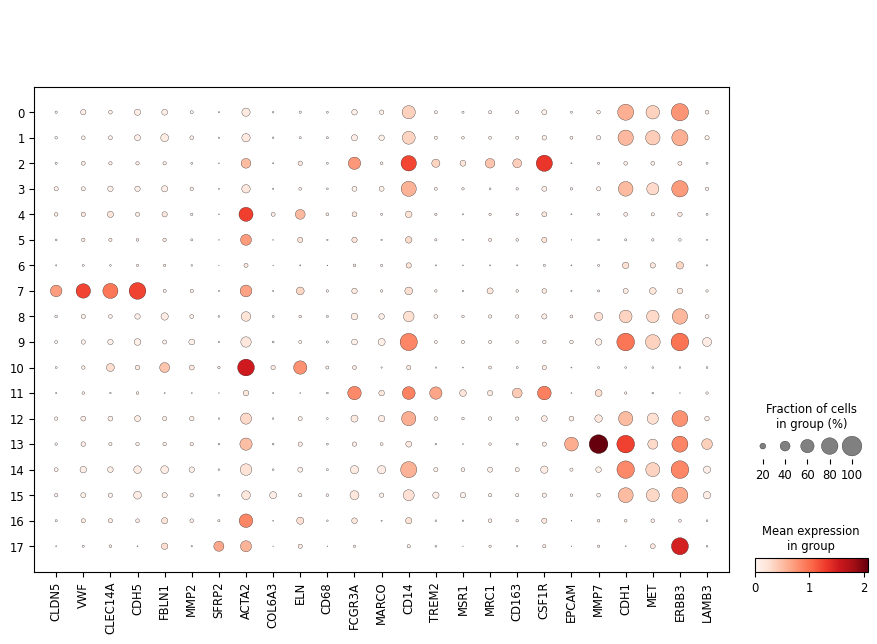

In [226]:
sc.pl.dotplot(adata_obj, [x for x in all_marker_genes if x in adata_obj.var.index], groupby='leiden')

In [16]:
sc.tl.rank_genes_groups(adata_obj, groupby='leiden', method='wilcoxon')

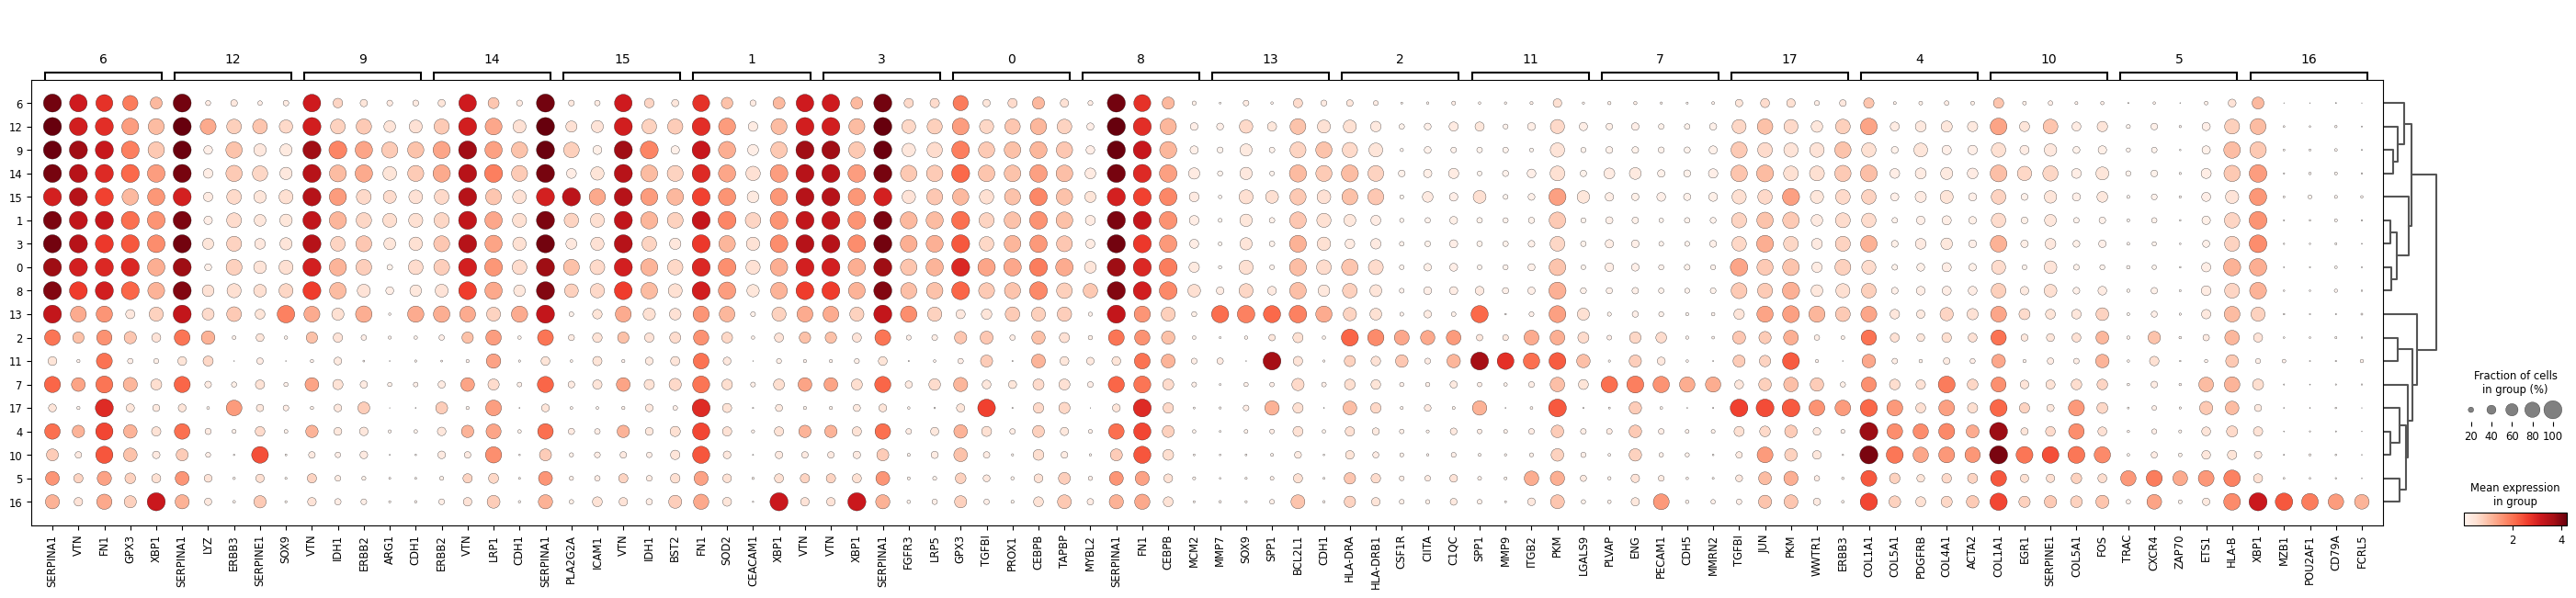

In [228]:
sc.pl.rank_genes_groups_dotplot(adata_obj, groupby='leiden', n_genes=5)

In [17]:
group_mean_expr = sc.get.aggregate(adata_obj, by='leiden', func=['mean', 'count_nonzero'])

In [18]:
marker_expr_matrix = pd.DataFrame(group_mean_expr.layers['mean'], index=group_mean_expr.obs.index, columns=group_mean_expr.var.index).reindex(columns=all_marker_genes).dropna(how='all', axis=1)

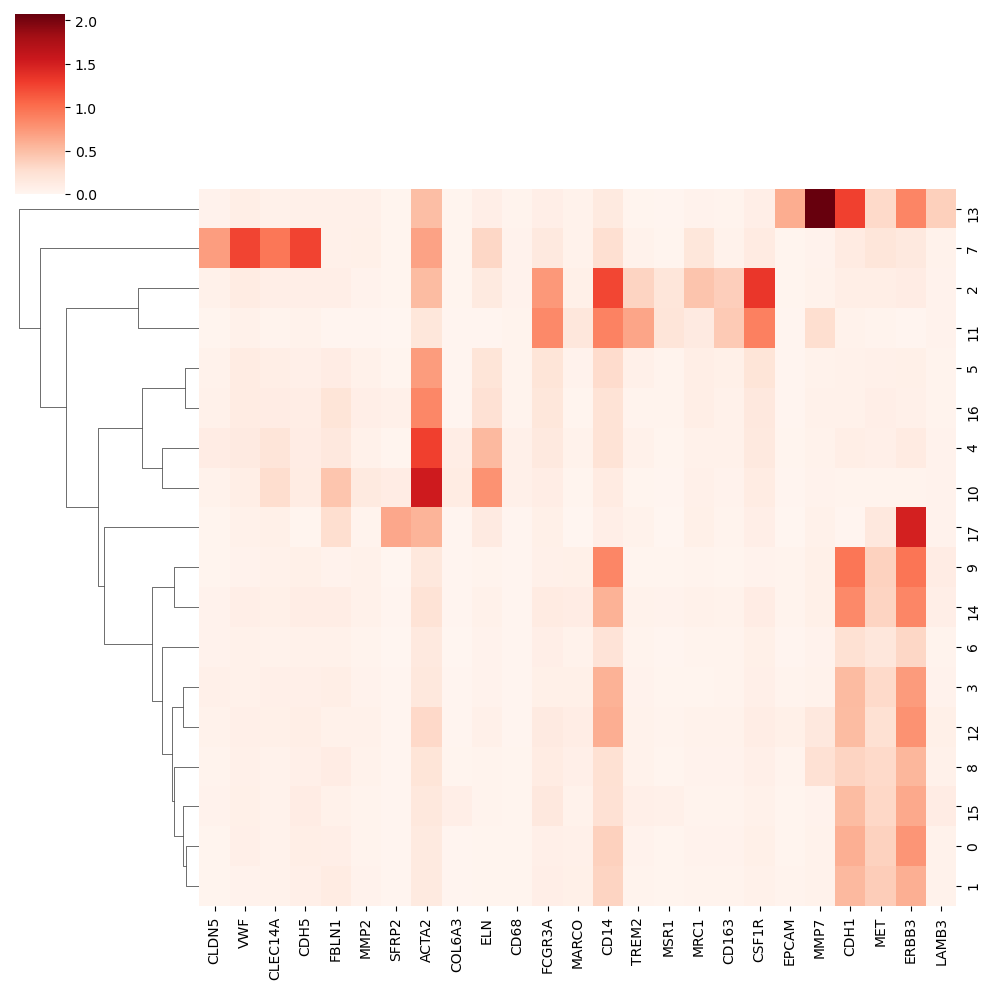

In [231]:
sns.clustermap(marker_expr_matrix, col_cluster=False, cmap='Reds')

In [19]:
average_marker_expr = marker_expr_matrix.T.merge(marker_gene_df, left_index=True, right_on='Gene').drop(['Gene'], axis=1).groupby('cell_type').mean()

Text(0.5, 1.0, 'Average marker geneset expression')

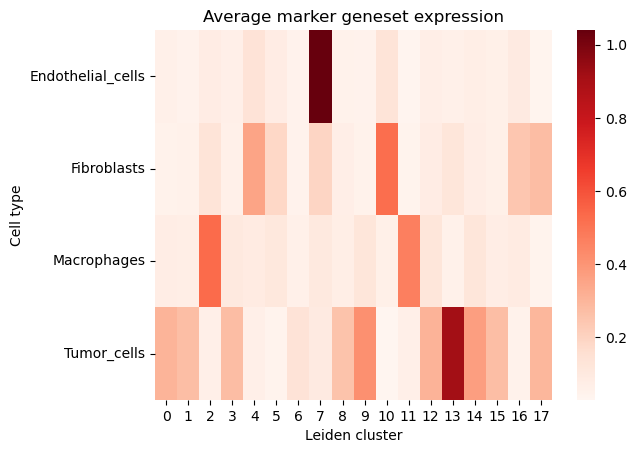

In [155]:
sns.heatmap(average_marker_expr, cmap='Reds')
plt.ylabel('Cell type')
plt.xlabel('Leiden cluster')
plt.title('Average marker geneset expression')

In [20]:
cluster_cell_type_assignment = pd.concat([
    average_marker_expr.idxmax(axis=0).rename('max_cell_type_expr'),
    (average_marker_expr > 0.25).sum(axis=0).rename('n_cell_type_expr')
], axis=1).reset_index(names=['leiden'])
cluster_cell_type_assignment['cell_type'] = cluster_cell_type_assignment.apply(lambda x: x['max_cell_type_expr'] if x['n_cell_type_expr'] == 1 else 'Unknown', axis=1)

In [21]:
adata_obj.obs = adata_obj.obs.reset_index().merge(cluster_cell_type_assignment[['leiden', 'cell_type']], how='left').set_index('index')

In [ ]:
adata_obj.write_h5ad(os.path.join(MERSCOPE_DATADIR, 'working_anndata.h5ad'))

## Process polygons

In [39]:
import h5py
from tqdm import tqdm

boundries_fn = os.listdir(os.path.join(MERSCOPE_DATADIR, 'cell_boundaries'))
cells = []
polygons = []
for bfn in tqdm(boundries_fn):
    bfn = os.path.join(MERSCOPE_DATADIR, 'cell_boundaries', bfn)
    f = h5py.File(bfn,'r')
    cell_coords = []
    for cell in list(f['featuredata']):
        coords = []
        tmp = np.array((f['featuredata'][cell]['zIndex_'+str(0)]['p_0']['coordinates'][0]))
        polygons.append(Polygon(tmp))
        cells.append('cell_'+str(int(cell)+1))
        coords.append(tmp)
    f.close()
cell_coords = pd.DataFrame(polygons, index=cells, columns=['polygon'])
cell_coords = GeoDataFrame(cell_coords, geometry='polygon')
cell_coords.to_parquet(os.path.join(MERSCOPE_DATADIR, 'cell_polygons.parquet'))

100%|██████████| 2517/2517 [01:55<00:00, 21.74it/s]


In [40]:
cell_coords = gpd.read_parquet(os.path.join(MERSCOPE_DATADIR, 'cell_polygons.parquet'))

In [43]:
adata_obj.obs = adata_obj.obs.reset_index().merge(cell_coords, left_on='index', right_index=True, how='left').set_index('index')

In [28]:
def write_geo_adata(adata, filename):
    adata_copy = adata.copy()
    geometry_columns = adata_obj.obs.dtypes[adata_obj.obs.dtypes == 'geometry'].index.tolist()
    adata_copy.obs = adata_copy.obs.drop(geometry_columns, axis=1)
    adata_copy.write_h5ad(filename)

In [4]:
def load_geo_h5ad(h5ad_filename, geo_parquet_filename):
    adata = sc.read_h5ad(h5ad_filename)
    geodata = gpd.read_parquet(geo_parquet_filename)
    adata.obs = adata.obs.reset_index().merge(geodata, left_on='index', right_index=True, how='left').set_index('index')
    return adata

In [67]:
adata_obj = load_geo_h5ad(os.path.join(MERSCOPE_DATADIR, 'working_anndata.h5ad'), os.path.join(MERSCOPE_DATADIR, 'cell_polygons.parquet'))

## Map transcripts to cells

In [ ]:
chunk_iterator = 0
tx_iterator = 0
for chunk in pd.read_csv(os.path.join(MERSCOPE_DATADIR, 'detected_transcripts.csv'), chunksize=100000, index_col=0):
    fovs = chunk['fov'].unique().tolist()
    if chunk_iterator == 0:
        with open(os.path.join(MERSCOPE_DATADIR, 'tx_annotation_progress.txt'), 'w') as f:
            f.write('processing chunk #{}:\n'.format(chunk_iterator+1))
    else:
        with open(os.path.join(MERSCOPE_DATADIR, 'tx_annotation_progress.txt'), 'a') as f:
            f.write('processing chunk #{}:\n'.format(chunk_iterator+1))
    chunk_genes = chunk[~chunk['gene'].str.contains('Blank')]

    for fov in fovs:
        fov_tx = chunk_genes[chunk_genes['fov'] == fov].copy()
        fov_tx.index = ['tx_' + str(i) for i in fov_tx.index]
        fov_cell = adata_obj.obs[adata_obj.obs['fov'].isin(fovs)]
        fov_tx.loc[:, 'point'] = fov_tx.apply(lambda x: Point(x.global_x, x.global_y), axis=1)
        points = np.repeat(fov_tx.point.values, fov_cell.shape[0])
        masks = fov_cell['polygon'].tolist() * fov_tx.shape[0]
        tx_mask_dist = distance(points, masks)
        crit = tx_mask_dist == 0
        tx_kept = np.repeat(fov_tx.index, fov_cell.shape[0])[crit]
        masks_kept = np.array(fov_cell.index.tolist() * fov_tx.shape[0])[crit]
        fov_tx.loc[tx_kept, 'cell'] = masks_kept
        fov_tx = fov_tx.dropna()
        fov_tx = fov_tx[['fov', 'global_x', 'global_y', 'gene', 'cell']]

        if tx_iterator == 0:
            fov_tx.to_csv(os.path.join(MERSCOPE_DATADIR, 'transcript_meta.csv'))
        else:
            fov_tx.to_csv(os.path.join(MERSCOPE_DATADIR, 'transcript_meta.csv'), mode='a', header=None)
        
        tx_iterator += fov_tx.shape[0]
        with open(os.path.join(MERSCOPE_DATADIR, 'tx_annotation_progress.txt'), 'a') as f:
            f.write('\tcumulative transcripts assigned: {}\n'.format(tx_iterator))
    chunk_iterator += 1

# Check rough cell arrangement

In [146]:
adata_obj = load_geo_h5ad(os.path.join(MERSCOPE_DATADIR, 'working_anndata.h5ad'), os.path.join(MERSCOPE_DATADIR, 'cell_polygons.parquet'))

([], [])

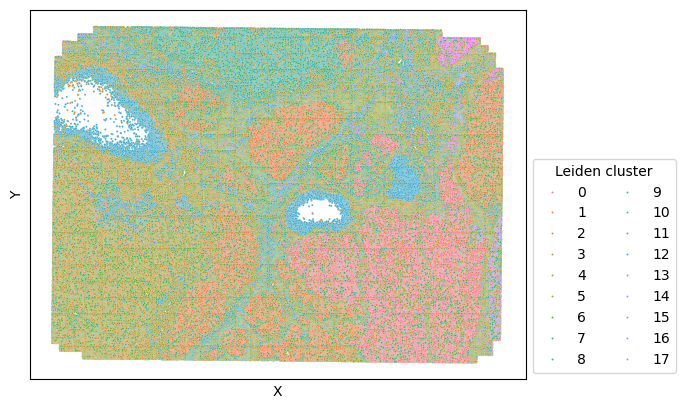

In [152]:
sns.scatterplot(adata_obj.obs, x='center_x', y='center_y', hue='leiden', s=2)
plt.legend(loc='lower left', bbox_to_anchor=(1, 0), ncol=2, title='Leiden cluster')
plt.xlabel('X')
plt.ylabel('Y')
plt.xticks([])
plt.yticks([])

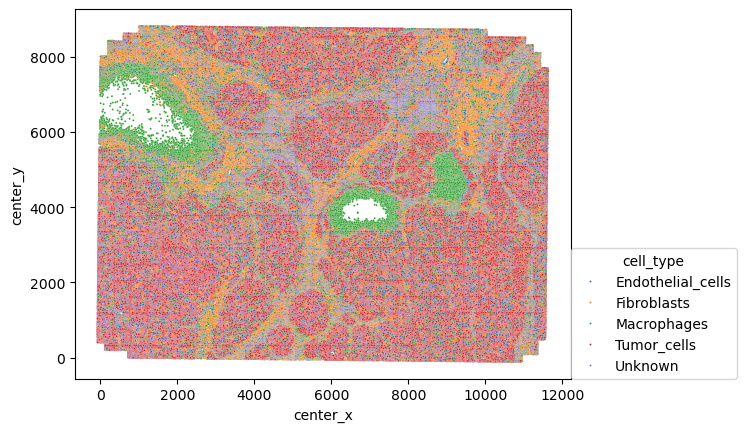

In [323]:
sns.scatterplot(adata_obj.obs, x='center_x', y='center_y', hue='cell_type', s=2)
plt.gca().get_legend().set_loc((1, 0))

/var/folders/h6/mz7d052n7mv3whgg0g3ck4f40000gn/T/ipykernel_93587/593618869.py:12: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  sns.scatterplot(adata_uq.obs.replace({'Unknown': 'Other'}), x='center_x', y='center_y', hue='cell_type', s=2, palette=celltype_cmap)


([], [])

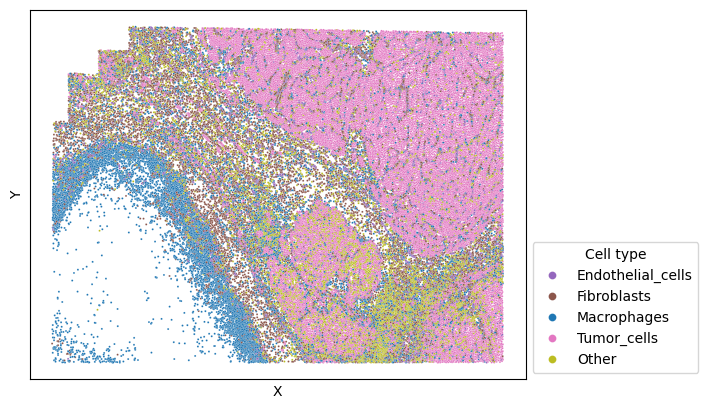

In [153]:
celltype_cmap = {
    'Tumor_cells': 'tab:pink', 
    'Fibroblasts': 'tab:brown',
    'Macrophages': 'tab:blue', 
    'Endothelial_cells': 'tab:purple',
    'Unknown': 'tab:olive',
    'Other': 'tab:olive'
}

adata_uq = adata_obj[(adata_obj.obs['center_x'] <= 6000) & ((adata_obj.obs['center_y'] >= 6000))].copy()
# plt.figure(figsize=(14, 10))
sns.scatterplot(adata_uq.obs.replace({'Unknown': 'Other'}), x='center_x', y='center_y', hue='cell_type', s=2, palette=celltype_cmap)
plt.legend(title='Cell type', loc='lower left', bbox_to_anchor=(1, 0), markerscale=4)
plt.xlabel('X')
plt.ylabel('Y')
plt.xticks([])
plt.yticks([])

/var/folders/h6/mz7d052n7mv3whgg0g3ck4f40000gn/T/ipykernel_93587/89238829.py:34: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  sns.scatterplot(adata_uq.obs.replace({'Unknown': 'Other'}), x='center_x', y='center_y', hue='cell_type', s=4, palette=celltype_cmap, ax=axs[2])


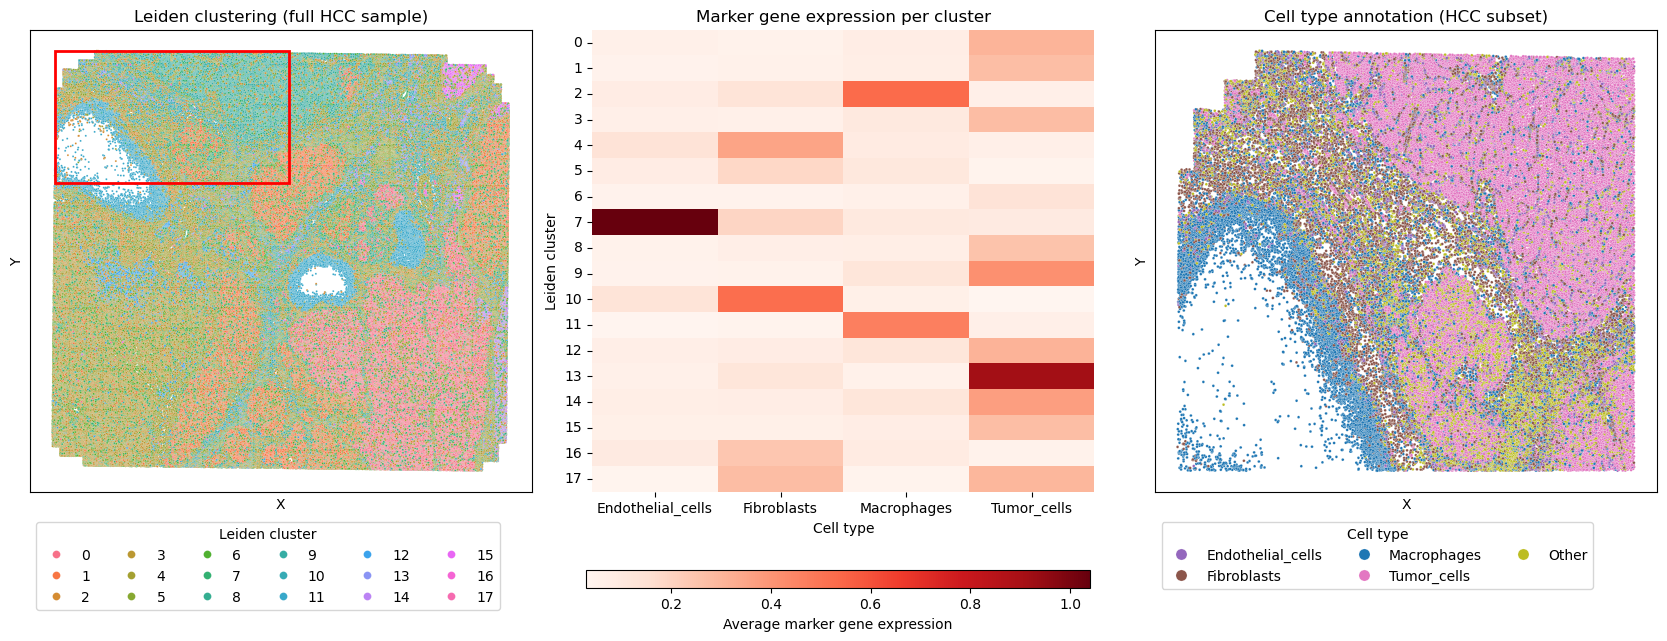

In [187]:
from matplotlib.patches import Rectangle

fig, axs = plt.subplots(1, 3, figsize=(21, 6), gridspec_kw={'wspace': 0.12})
sns.scatterplot(adata_obj.obs, x='center_x', y='center_y', hue='leiden', s=2, ax=axs[0])
axs[0].legend(loc='upper left', bbox_to_anchor=(0, -0.05), ncol=6, title='Leiden cluster', markerscale=4)
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[0].set_xticks([])
axs[0].set_yticks([])
axs[0].set_title('Leiden clustering (full HCC sample)')

# Define rectangle: (x, y), width, height, edgecolor, facecolor
rect = Rectangle((0, 6000), 6000, 2800, edgecolor='red', facecolor='none', linewidth=2)
axs[0].add_patch(rect)

hm = sns.heatmap(average_marker_expr.T, cmap='Reds', ax=axs[1], cbar=False)
                #  cbar_kws={'label': 'Average marker gene expression', 'orientation': 'horizontal'})
axs[1].set_xlabel('Cell type')
axs[1].set_ylabel('Leiden cluster')
axs[1].tick_params(axis='y', labelrotation=0)
axs[1].set_title('Marker gene expression per cluster')

celltype_cmap = {
    'Tumor_cells': 'tab:pink', 
    'Fibroblasts': 'tab:brown',
    'Macrophages': 'tab:blue', 
    'Endothelial_cells': 'tab:purple',
    'Unknown': 'tab:olive',
    'Other': 'tab:olive'
}

adata_uq = adata_obj[(adata_obj.obs['center_x'] <= 6000) & ((adata_obj.obs['center_y'] >= 6000))].copy()
# plt.figure(figsize=(14, 10))
sns.scatterplot(adata_uq.obs.replace({'Unknown': 'Other'}), x='center_x', y='center_y', hue='cell_type', s=4, palette=celltype_cmap, ax=axs[2])
# axs[2].legend(title='Cell type', loc='lower left', bbox_to_anchor=(1, 0), markerscale=4)
axs[2].legend(loc='upper left', bbox_to_anchor=(0, -0.05), ncol=3, title='Cell type', markerscale=4)
axs[2].set_xlabel('X')
axs[2].set_ylabel('Y')
axs[2].set_xticks([])
axs[2].set_yticks([])
axs[2].set_title('Cell type annotation (HCC subset)')

# --- GLOBAL COLORBAR BELOW ALL PLOTS ---
cbar_ax = fig.add_axes([0.39, -0.05, 0.24, 0.03])  # [left, bottom, width, height]

fig.colorbar(
    hm.collections[0],
    cax=cbar_ax,
    orientation='horizontal',
    label='Average marker gene expression'
)

plt.show()

## Sanity check that transcript assignment is close to the provided cell by gene matrix

In [7]:
adata_obj = load_geo_h5ad(os.path.join(MERSCOPE_DATADIR, 'working_anndata.h5ad'), os.path.join(MERSCOPE_DATADIR, 'cell_polygons.parquet'))

In [9]:
full_tx_meta = pd.read_csv(os.path.join(MERSCOPE_DATADIR, 'transcript_meta.csv'))

In [11]:
cell_by_gene_tx_reassigned = pd.pivot_table(full_tx_meta, index='cell', columns='gene', aggfunc='count', values='fov')

In [14]:
cell_by_gene_provided = pd.DataFrame(adata_obj.layers['count'].todense(), index=adata_obj.obs_names, columns=adata_obj.var_names)

In [18]:
(cell_by_gene_tx_reassigned.reindex_like(cell_by_gene_provided).fillna(0) == cell_by_gene_provided).sum().sum() / (cell_by_gene_provided.shape[0] * cell_by_gene_provided.shape[1])

0.9920288726633164

In [38]:
nz_reassigned = cell_by_gene_tx_reassigned.reindex_like(cell_by_gene_provided).fillna(0)
nz_reassigned = nz_reassigned[nz_reassigned != 0]

nz_provided = cell_by_gene_provided
nz_provided = nz_provided[nz_provided != 0]

In [40]:
(nz_reassigned == nz_provided).sum().sum() / (~(nz_reassigned.isna()) | ~(nz_provided.isna())).sum().sum()

0.9606592414216278

In [20]:
total_count_differences = (cell_by_gene_tx_reassigned.reindex_like(cell_by_gene_provided).fillna(0).sum() - cell_by_gene_provided.sum()).sort_values()

In [26]:
total_count_differences = cell_by_gene_tx_reassigned.reindex_like(cell_by_gene_provided).fillna(0) - cell_by_gene_provided

In [21]:
total_count_differences.head(25)

SERPINA1   -1268563.0
VTN         -570107.0
FN1         -474271.0
GPX3        -214254.0
COL1A1      -119124.0
CEBPB        -82012.0
SOD2         -80609.0
LRP1         -71591.0
XBP1         -62610.0
VEGFA        -61029.0
IDH1         -60342.0
AKT1         -60026.0
IL6R         -57469.0
ITGB1        -54350.0
DUSP1        -45726.0
PROX1        -45459.0
PKM          -45321.0
BCL2L1       -44365.0
PLA2G2A      -43457.0
JUN          -43166.0
TAPBP        -40406.0
NFKBIA       -39840.0
CTNNB1       -39156.0
LRP5         -38948.0
HLA-B        -38840.0
dtype: float64

In [35]:
adata_obj.obs[['cell_type']].value_counts()

cell_type        
Tumor_cells          262838
Unknown               84105
Fibroblasts           69787
Macrophages           68319
Endothelial_cells     36898
Name: count, dtype: int64

<Axes: xlabel='cell_type', ylabel='SERPINA1'>

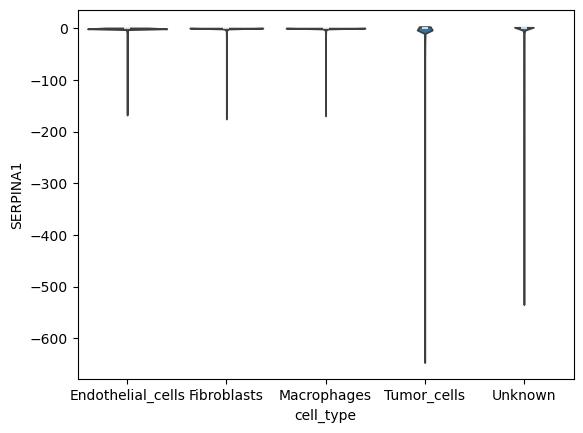

In [32]:
g = 'SERPINA1'
sns.violinplot(
    total_count_differences[[g]].merge(adata_obj.obs[['cell_type']], left_index=True, right_index=True),
    x='cell_type', y=g
)

<Axes: xlabel='cell_type', ylabel='VTN'>

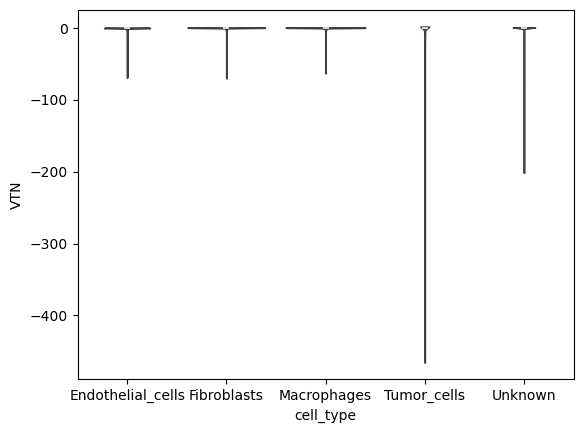

In [44]:
g = 'VTN'
sns.violinplot(
    total_count_differences[[g]].merge(adata_obj.obs[['cell_type']], left_index=True, right_index=True),
    x='cell_type', y=g
)

<Axes: xlabel='cell_type', ylabel='FN1'>

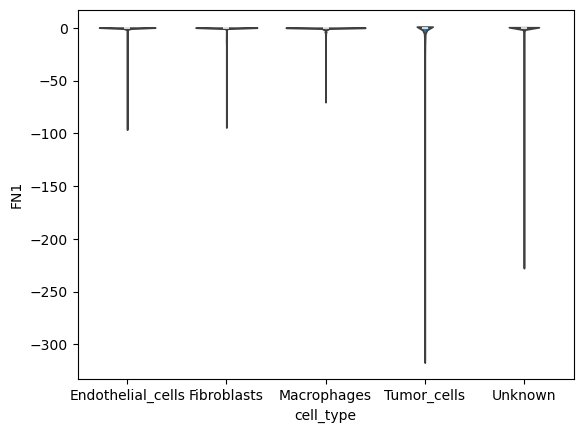

In [36]:
g = 'FN1'
sns.violinplot(
    total_count_differences[[g]].merge(adata_obj.obs[['cell_type']], left_index=True, right_index=True),
    x='cell_type', y=g
)

<Axes: xlabel='cell_type', ylabel='GPX3'>

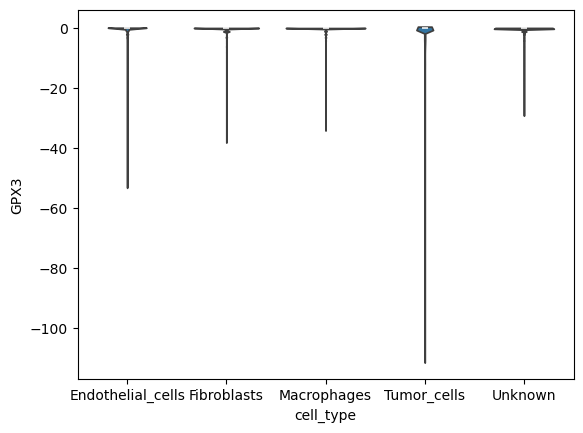

In [37]:
g = 'GPX3'
sns.violinplot(
    total_count_differences[[g]].merge(adata_obj.obs[['cell_type']], left_index=True, right_index=True),
    x='cell_type', y=g
)

<Axes: xlabel='cell_type', ylabel='COL1A1'>

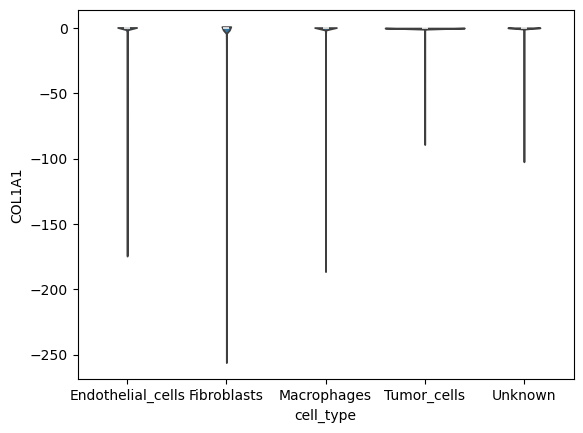

In [42]:
g = 'COL1A1'
sns.violinplot(
    total_count_differences[[g]].merge(adata_obj.obs[['cell_type']], left_index=True, right_index=True),
    x='cell_type', y=g
)

In [46]:
cell_metadata = pd.read_csv(os.path.join(MERSCOPE_DATADIR, 'cell_metadata.csv'), index_col=0)
cell_metadata.index = ['cell_' + str(i+1) for i in cell_metadata.index]
gene_metadata = pd.DataFrame(index=cell_by_gene_tx_reassigned.columns)
gene_metadata['control_probe'] = gene_metadata.index.str.contains('Blank')

In [57]:
new_adata_obj = sc.AnnData(X = csc_matrix(cell_by_gene_tx_reassigned.fillna(0)), obs=cell_metadata.reindex(index=cell_by_gene_tx_reassigned.index), var=gene_metadata.reindex(index=cell_by_gene_tx_reassigned.columns))
new_adata_obj.obs['total_counts'] = new_adata_obj.X.sum(axis=1)
new_adata_obj.obs['total_transcript_counts'] = new_adata_obj[:, ~new_adata_obj.var['control_probe']].X.sum(axis=1)
new_adata_obj.write_h5ad(os.path.join(MERSCOPE_DATADIR, 'full_anndata_tx_reassigned.h5ad'))

In [58]:
adata_obj = sc.read_h5ad(os.path.join(MERSCOPE_DATADIR, 'full_anndata_tx_reassigned.h5ad'))
adata_obj = adata_obj[adata_obj.obs['total_transcript_counts'] >= 20, ~adata_obj.var['control_probe']]
adata_obj.layers['count'] = adata_obj.copy().X
sc.pp.normalize_total(adata_obj)
sc.pp.log1p(adata_obj)

/var/folders/h6/mz7d052n7mv3whgg0g3ck4f40000gn/T/ipykernel_61890/2160585333.py:3: ImplicitModificationWarning: Setting element `.layers['count']` of view, initializing view as actual.
  adata_obj.layers['count'] = adata_obj.copy().X


In [59]:
sc.tl.pca(adata_obj)
sc.pp.neighbors(adata_obj)

In [60]:
sc.tl.leiden(adata_obj)

/var/folders/h6/mz7d052n7mv3whgg0g3ck4f40000gn/T/ipykernel_61890/1474956021.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_obj)


In [61]:
group_mean_expr = sc.get.aggregate(adata_obj, by='leiden', func=['mean', 'count_nonzero'])

In [62]:
marker_expr_matrix = pd.DataFrame(group_mean_expr.layers['mean'], index=group_mean_expr.obs.index, columns=group_mean_expr.var.index).reindex(columns=all_marker_genes).dropna(how='all', axis=1)

In [63]:
average_marker_expr = marker_expr_matrix.T.merge(marker_gene_df, left_index=True, right_on='Gene').drop(['Gene'], axis=1).groupby('cell_type').mean()

Text(0.5, 1.0, 'Average marker geneset expression')

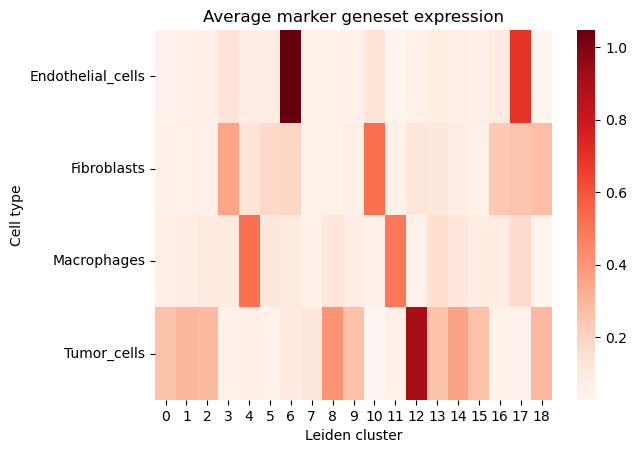

In [64]:
sns.heatmap(average_marker_expr, cmap='Reds')
plt.ylabel('Cell type')
plt.xlabel('Leiden cluster')
plt.title('Average marker geneset expression')

In [65]:
cluster_cell_type_assignment = pd.concat([
    average_marker_expr.idxmax(axis=0).rename('max_cell_type_expr'),
    (average_marker_expr > 0.25).sum(axis=0).rename('n_cell_type_expr')
], axis=1).reset_index(names=['leiden'])
cluster_cell_type_assignment['cell_type'] = cluster_cell_type_assignment.apply(lambda x: x['max_cell_type_expr'] if x['n_cell_type_expr'] == 1 else 'Unknown', axis=1)

In [70]:
adata_obj.obs = adata_obj.obs.reset_index().merge(cluster_cell_type_assignment[['leiden', 'cell_type']], how='left').set_index('cell')

In [72]:
adata_obj.write_h5ad(os.path.join(MERSCOPE_DATADIR, 'working_anndata_tx_reassigned.h5ad'))

In [78]:
new_adata_obj = sc.read_h5ad(os.path.join(MERSCOPE_DATADIR, 'working_anndata_tx_reassigned.h5ad'))
old_adata_obj = sc.read_h5ad(os.path.join(MERSCOPE_DATADIR, 'working_anndata.h5ad'))

/var/folders/h6/mz7d052n7mv3whgg0g3ck4f40000gn/T/ipykernel_61890/4185999200.py:14: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  sns.scatterplot(adata_uq1.obs.replace({'Unknown': 'Other'}), x='center_x', y='center_y', hue='cell_type', s=4, palette=celltype_cmap, ax=axs[0])
/var/folders/h6/mz7d052n7mv3whgg0g3ck4f40000gn/T/ipykernel_61890/4185999200.py:25: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  sns.scatterplot(adata_uq2.obs.replace({'Unknown': 'Other'}), x='center_x', y='center_y', hue='cell_type', s=4, palette=celltype_cmap, ax=axs[1])


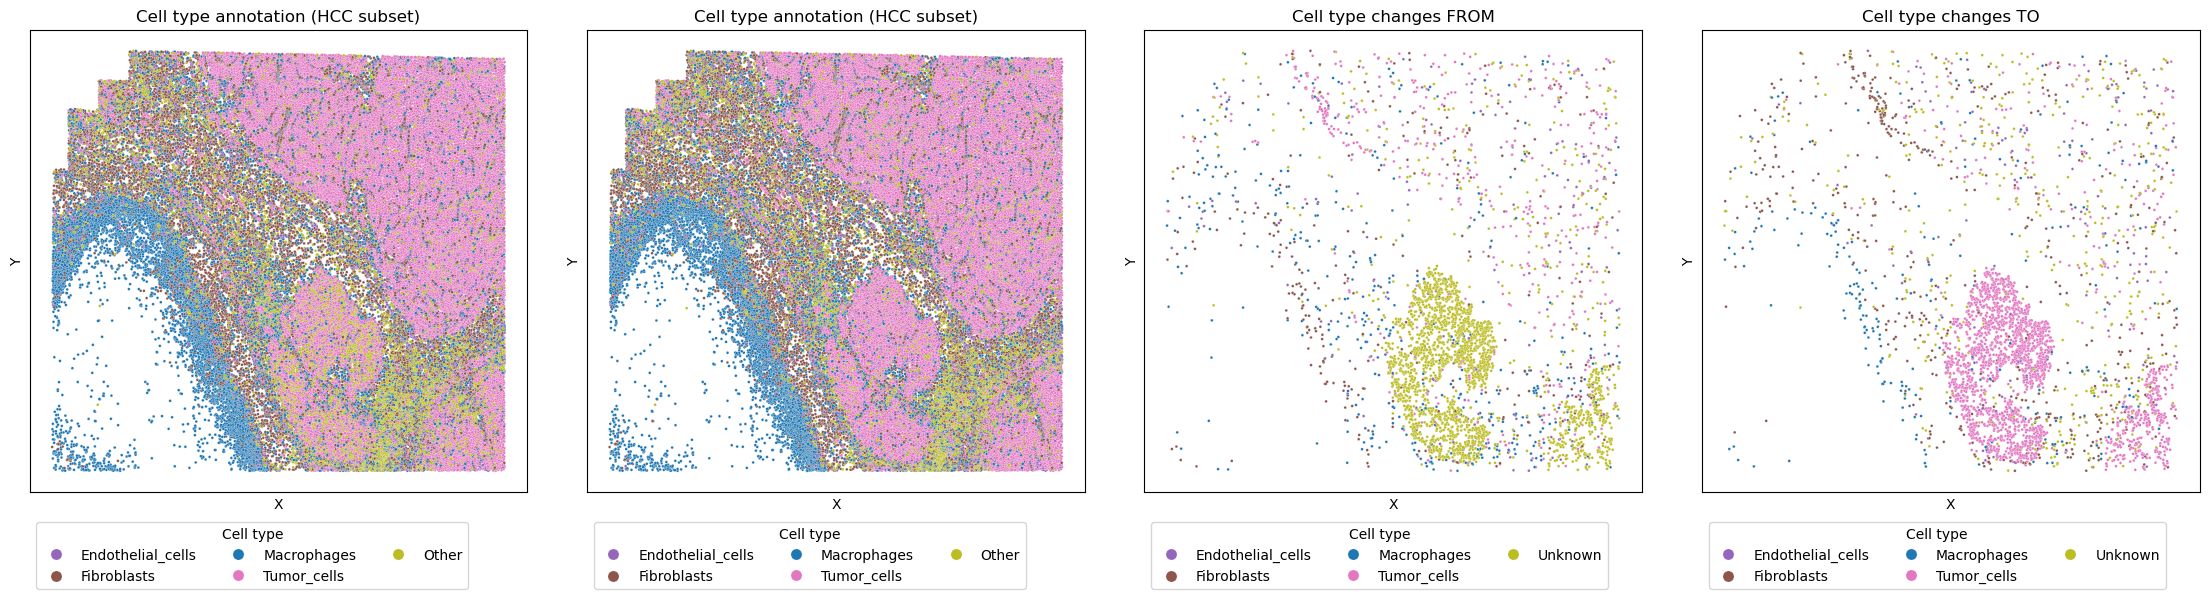

In [96]:
celltype_cmap = {
    'Tumor_cells': 'tab:pink', 
    'Fibroblasts': 'tab:brown',
    'Macrophages': 'tab:blue', 
    'Endothelial_cells': 'tab:purple',
    'Unknown': 'tab:olive',
    'Other': 'tab:olive'
}

fig, axs = plt.subplots(1, 4, figsize=(28, 6), gridspec_kw={'wspace': 0.12})

adata_uq1 = old_adata_obj[(old_adata_obj.obs['center_x'] <= 6000) & ((old_adata_obj.obs['center_y'] >= 6000))].copy()
# plt.figure(figsize=(14, 10))
sns.scatterplot(adata_uq1.obs.replace({'Unknown': 'Other'}), x='center_x', y='center_y', hue='cell_type', s=4, palette=celltype_cmap, ax=axs[0])
# axs[2].legend(title='Cell type', loc='lower left', bbox_to_anchor=(1, 0), markerscale=4)
axs[0].legend(loc='upper left', bbox_to_anchor=(0, -0.05), ncol=3, title='Cell type', markerscale=4)
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[0].set_xticks([])
axs[0].set_yticks([])
axs[0].set_title('Cell type annotation (HCC subset)')

adata_uq2 = new_adata_obj[(new_adata_obj.obs['center_x'] <= 6000) & ((new_adata_obj.obs['center_y'] >= 6000))].copy()
# plt.figure(figsize=(14, 10))
sns.scatterplot(adata_uq2.obs.replace({'Unknown': 'Other'}), x='center_x', y='center_y', hue='cell_type', s=4, palette=celltype_cmap, ax=axs[1])
# axs[2].legend(title='Cell type', loc='lower left', bbox_to_anchor=(1, 0), markerscale=4)
axs[1].legend(loc='upper left', bbox_to_anchor=(0, -0.05), ncol=3, title='Cell type', markerscale=4)
axs[1].set_xlabel('X')
axs[1].set_ylabel('Y')
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[1].set_title('Cell type annotation (HCC subset)')

sns.scatterplot(adata_uq1.obs[adata_uq1.obs['cell_type'] != adata_uq2.obs['cell_type'].reindex(index=adata_uq1.obs.index.tolist())], 
                x='center_x', y='center_y', hue='cell_type', s=4, palette=celltype_cmap, ax=axs[2])
axs[2].legend(loc='upper left', bbox_to_anchor=(0, -0.05), ncol=3, title='Cell type', markerscale=4)
axs[2].set_xlabel('X')
axs[2].set_ylabel('Y')
axs[2].set_xticks([])
axs[2].set_yticks([])
axs[2].set_title('Cell type changes FROM')

sns.scatterplot(adata_uq2.obs[adata_uq1.obs['cell_type'].reindex(index=adata_uq2.obs.index.tolist()) != adata_uq2.obs['cell_type']], 
                x='center_x', y='center_y', hue='cell_type', s=4, palette=celltype_cmap, ax=axs[3])
axs[3].legend(loc='upper left', bbox_to_anchor=(0, -0.05), ncol=3, title='Cell type', markerscale=4)
axs[3].set_xlabel('X')
axs[3].set_ylabel('Y')
axs[3].set_xticks([])
axs[3].set_yticks([])
axs[3].set_title('Cell type changes TO')

plt.show()

# Generate synthetic datasets with transcript swapping

In [5]:
def calculate_mask_distance(
    centroid_dist: pd.DataFrame,
    cell_coords: pd.DataFrame,
    max_centroid_dist: int = 15,
    min_centroid_dist: int = 0,
    cluster_col:str = 'leiden',
    x_col:str = 'x',
    y_col:str = 'y',
    geometry_col:str = 'Geometry',
    re_cal_centroid_dist:bool = False
    ):
    '''
    centroid_dist: cell by cell distance matrix by centroid location, 
    max_centroid_dist: maximal distance to consider neighbors, 
    max_centroid_dist: minimal distance to consider distant cells, 
    cell_coords: cell by cell distance matrix by centroid location, 
    centroid_dist: cell by cell distance matrix by centroid location, 
    '''
    adj = (centroid_dist > min_centroid_dist) & (centroid_dist<= max_centroid_dist)
    adj = adj.agg(
        lambda x: adj.columns[x.values].tolist(), axis=1)
    adj = pd.DataFrame(adj, columns = ['n'])
    # pandas suggest using transform, but it did not work.
    adj = adj.agg(
        lambda x: [
            y for y in x.n if cell_coords.loc[y, cluster_col]!=cell_coords.loc[x.name, cluster_col]
            ], axis=1)
    adj_nonself = adj[adj.apply(len)>0]
    adj_nonself_masks_ids = adj_nonself.explode()
    md = distance(
        cell_coords.loc[adj_nonself_masks_ids.index, geometry_col].values,
        cell_coords.loc[adj_nonself_masks_ids.values, geometry_col].values
    )
    masks_distances = pd.DataFrame(
        adj_nonself_masks_ids, columns=['neighbor_by_centroid'])
    masks_distances['mask_distance'] = md
    # recalculating the centroid distance is expensive, so it should be avoided
    if re_cal_centroid_dist:
        v1 = cell_coords.loc[masks_distances.index, [x_col, y_col]].values
        v2 = cell_coords.loc[masks_distances.neaghbor_by_centroid, [x_col, y_col]].values
        masks_distances['centroid_distance'] = np.sum((v1-v2)**2, axis=1)**0.5
    return masks_distances

In [8]:
def load_geo_h5ad(h5ad_filename, geo_parquet_filename):
    adata = sc.read_h5ad(h5ad_filename)
    geodata = gpd.read_parquet(geo_parquet_filename)
    index_name = adata.obs.index.name
    adata.obs = adata.obs.reset_index().merge(geodata, left_on=index_name, right_index=True, how='left').set_index(index_name)
    return adata

In [17]:
tx_meta = pd.read_csv('../data/merscope_hcc1/transcript_meta.csv', index_col=0)
adata_obj = load_geo_h5ad(os.path.join(MERSCOPE_DATADIR, 'working_anndata_tx_reassigned.h5ad'), os.path.join(MERSCOPE_DATADIR, 'cell_polygons.parquet'))
adata_obj.X = adata_obj.layers['count']

In [18]:
def prepare_permutation_scheme(adata_obj, tx_meta):
    """
    Subset the HCC1 dataset and identify the tumor:non-tumor boundary

    Args:
        h5ad_filename (str): the filepath of the AnnData object
        geo_parquet_filename (str): the filepath of the parquet file containing cell boundary coordinates
    """
    adata_uq = adata_obj[(adata_obj.obs['center_x'] <= 6000) & ((adata_obj.obs['center_y'] >= 6000))].copy()

    cell_dist = cdist(
        adata_uq[adata_uq.obs['cell_type'] == 'Tumor_cells'].obs[['center_x', 'center_y']],
        adata_uq[adata_uq.obs['cell_type'] != 'Tumor_cells'].obs[['center_x', 'center_y']]
    )

    cell_dist = pd.DataFrame(
        cell_dist, 
        index = adata_uq[adata_uq.obs['cell_type'] == 'Tumor_cells'].obs_names, 
        columns = adata_uq[adata_uq.obs['cell_type'] != 'Tumor_cells'].obs_names
    )

    cell_meta = adata_uq.obs.copy()

    mask_distance = calculate_mask_distance(
        cell_dist,
        cell_meta,
        max_centroid_dist=30,
        x_col='X',
        y_col='Y',
        cluster_col = 'cell_type',
        geometry_col='polygon'
    )

    interface_tumor = mask_distance[mask_distance.mask_distance <= 2].index.unique()
    non_tumor_samples = adata_uq[adata_uq.obs['cell_type']!='Tumor_cells'].to_df().sample(len(interface_tumor)).index

    tx_interface = tx_meta[tx_meta['cell'].isin(interface_tumor)].copy()
    tx_interface['permuted_cell'] = pd.Series(non_tumor_samples, index=interface_tumor)[tx_interface['cell']].values
    tx_interface['permuted_celltype'] = cell_meta.loc[tx_interface['permuted_cell'],'cell_type'].values
    
    permuted_tx_interface = []
    print('Replace interface tumor cell transcripts with non tumor transcripts')
    for _,df in tqdm(tx_interface.groupby('permuted_celltype')):
        tx_ref = tx_meta[tx_meta['cell'].isin(df['permuted_cell'].unique())]
        permuted_genes = tx_ref['gene'].sample(df.shape[0], replace=True).values
        df['permuted_gene'] = permuted_genes
        permuted_tx_interface.append(df)
    permuted_tx_interface = pd.concat(permuted_tx_interface)

    sample_celltypes = adata_uq.obs.loc[non_tumor_samples,'cell_type'].astype(str).values
    # Construct the interface adata with swapped cells
    # The interface cells will have the same cell id but swapped gene expression.
    adata_interface = adata_uq[interface_tumor].copy()
    adata_interface.X = adata_uq[non_tumor_samples].layers['count']
    adata_interface.layers['Raw'] = adata_interface.X.copy()
    adata_interface.obs['cell_type'] = sample_celltypes

    # Construct the synthetic data by merging the orphan tumors adata and the synthetic interface adata
    adata_uq_others = adata_uq[~adata_uq.obs_names.isin(interface_tumor)]
    adata_synthetic = sc.concat([adata_uq_others, adata_interface])
    # Remake the metadata

    cell_meta_synthetic = cell_meta.copy()
    cell_meta_synthetic.loc[interface_tumor, 'cell_type'] = sample_celltypes

    # Identify tumor cells to add transcripts to
    # Need to recalculate tumor to non tumor cell distance as the cell identify was changed
    cell_dist_synthetic = pd.DataFrame(
        cdist(
            adata_synthetic[adata_synthetic.obs['cell_type'] == 'Tumor_cells'].obs[['center_x', 'center_y']],
            adata_synthetic[adata_synthetic.obs['cell_type'] != 'Tumor_cells'].obs[['center_x', 'center_y']]
        ),
        index = adata_synthetic[adata_synthetic.obs['cell_type'] == 'Tumor_cells'].obs_names, 
        columns = adata_synthetic[adata_synthetic.obs['cell_type'] != 'Tumor_cells'].obs_names
    )

    mask_distance_synthetic = calculate_mask_distance(
        cell_dist_synthetic,
        cell_meta_synthetic,
        max_centroid_dist=30,
        x_col='X',
        y_col='Y',
        cluster_col = 'cell_type',
        geometry_col='polygon'
    )
    
    return cell_dist_synthetic, cell_meta_synthetic, mask_distance_synthetic, adata_synthetic, permuted_tx_interface

In [19]:
def generate_synthetic_dataset(
    cell_dist_synthetic, cell_meta_synthetic, mask_distance_synthetic, adata_synthetic, permuted_tx_interface, outfile,
    max_noise_tx=5, n_points=1000, doublet_prob=0.2, tx2m_dist=1, deg_max_p=0.05, deg_min_effect=0.6, tumor_deg_max_p=0.05, tumor_deg_min_effect=1,
    max_pct_tumor = 0.5, min_pct_diff = 0.2, max_pct_other = 0.15, min_pct_tumor = 0.5,
    seed=None
):
    """

    Args:
        cell_dist_synthetic (_type_): _description_
        cell_meta_synthetic (_type_): _description_
        mask_distance_synthetic (_type_): _description_
        adata_synthetic (_type_): _description_
        permuted_tx_interface (_type_): _description_
        outfile (_type_): _description_
        max_noise_tx (int, optional): max_noise_tx = 5 # number of transcripts per cell to swap. Defaults to 5.
        n_points (int, optional): _description_. Defaults to 1000.
        doublet_prob (float, optional): fraction of tumor interface cells in which to simulate spillover. Defaults to 0.2.
        tx2m_dist (int, optional): maximum distance between transcripts and cell boundaries for swapping. Defaults to 1.
        deg_max_p (float, optional): Defaults to 0.05.
        deg_min_effect (float, optional): .
        tumor_deg_max_p (float, optional): Defaults to 0.05.
        tumor_deg_min_effect (float, optional): Defaults to 1.
        max_pct_tumor (float, optional): maximum expression frequency in tumor cells for non-tumor DEGs. Defaults to 0.5.
        min_pct_diff (float, optional): minimum difference in expression frequency between ingroup vs all rest. Defaults to 0.2.
        max_pct_other (float, optional): maximum expression frequency in other cells for tumor DEGs. Defaults to 0.6. Defaults to 0.15.
        min_pct_tumor (float, optional): minimum expression frequency in tumor cells for tumor DEGs. Defaults to 0.5.
        seed (_type_, optional): _description_. Defaults to None.

    Returns:
        _type_: _description_
    """
    if seed is not None:
        np.random.seed(seed)
    
    interface_synthetic = mask_distance_synthetic[mask_distance_synthetic.mask_distance<0.5].copy()
    interface_synthetic['tumor_cell'] = interface_synthetic.index
    interface_synthetic = interface_synthetic.sort_values('mask_distance')
    # only simulated TX from one neighbor. 
    # TXs from another neighbor is conceptually equivalent and computationally a simple repeat.
    interface_synthetic.drop_duplicates('tumor_cell', inplace=True)
    # doublet level means the fraction of cell in the interaface to have at least one added TX
    print('Simulating TX points in {} cells. up to {} in each'.format(len(interface_synthetic), max_noise_tx))
    simulated_points_pos = {}
    simulated_points_neg = {}
    
    neighbors = []
    rng = np.random.default_rng()
    for tumor_cell in interface_synthetic.index:
        num_neg_tx = num_pos_tx = np.random.randint(1, max_noise_tx)
        tumor_p = cell_meta_synthetic.loc[tumor_cell,'polygon']
        points = np.array(GeoSeries(tumor_p).sample_points(size=n_points).iloc[0].geoms)
        neg_mask = np.zeros(1000, dtype=bool)
        neg_mask[rng.choice(1000,size=num_neg_tx, replace=False)] = True
        neg_points = points[neg_mask]
        simulated_points_neg[tumor_cell] = neg_points
        points = points[~neg_mask]
        if np.random.uniform(0,1,1) < doublet_prob:
            continue
        neighbor = interface_synthetic.loc[tumor_cell,'neighbor_by_centroid']
        neighbor_p = cell_meta_synthetic.loc[neighbor,'polygon']
        dist_to_neighbor = distance(
            points, np.repeat(neighbor_p,n_points - num_neg_tx)
        )
        pos_points = np.random.choice(
            points[dist_to_neighbor<tx2m_dist],
            min(num_pos_tx,(dist_to_neighbor<tx2m_dist).sum()),
            replace=False
        )
        if len(pos_points)==0:
            continue
        simulated_points_pos[tumor_cell]= pos_points
        neighbors += [neighbor] * len(pos_points)

    # Differential analysis
    print('Assign each TX point to a DEG from neighbor cell.')
    
    adata_synthetic.X = adata_synthetic.layers['count'].copy()
    adata_synthetic.raw = adata_synthetic.copy()
    sc.pp.normalize_total(adata_synthetic, target_sum=1000)
    sc.pp.log1p(adata_synthetic)
    sc.tl.rank_genes_groups(adata_synthetic, 'cell_type', pts=True, tie_correct=True, use_raw=False)
    deg = sc.get.rank_genes_groups_df(adata_synthetic, None)
    deg = deg.merge(deg[deg['group']=='Tumor_cells'][['names', 'pct_nz_group']].rename({'pct_nz_group': 'pct_nz_Tumor_cells'}, axis=1),on='names')

    # Filter the deg that can be added to synthetic target cells
    deg = deg[
        (deg['pvals_adj'] <= deg_max_p) & 
        (deg['logfoldchanges'] >= deg_min_effect) &
        (deg['pct_nz_Tumor_cells'] <= max_pct_tumor) & 
        ((deg['pct_nz_group'] - deg['pct_nz_reference']) >= min_pct_diff)
    ]
    print('# DEGs that can be synthetically added:', deg.shape[0])

    ct_deg = deg.groupby('group').names.agg(lambda x : x.tolist())

    # Identify genes selectively expressed in tumor cells
    non_tumor_genes = np.unique(ct_deg.sum())
    tumor_deg = sc.get.rank_genes_groups_df(
        adata_synthetic, 'Tumor_cells', log2fc_min=tumor_deg_min_effect, pval_cutoff=tumor_deg_max_p)
    tumor_genes = tumor_deg[
        (tumor_deg['pct_nz_reference'] <= max_pct_other) & 
        (tumor_deg['pct_nz_group'] >= min_pct_tumor)
    ].names.values
    tumor_genes = [x for x in tumor_genes if x not in non_tumor_genes]

    # Randomly assign gene symbol for each simulated transcript
    interface_synthetic['neighbor_ct'] = cell_meta_synthetic.loc[
        interface_synthetic['neighbor_by_centroid'].values, 'cell_type'].values
    interface_synthetic.loc[simulated_points_pos.keys(),'synthetic_pos'] = pd.Series(
        [*simulated_points_pos.values()]).values
    interface_synthetic.loc[simulated_points_neg.keys(),'synthetic_neg'] = pd.Series(
        [*simulated_points_neg.values()]).values
    interface_synthetic.loc[
        interface_synthetic['synthetic_pos'].notnull(), 'pos_symbol'
        ] = interface_synthetic.loc[interface_synthetic['synthetic_pos'].notnull()].apply(
        lambda x: np.random.choice(
            ct_deg.loc[x['neighbor_ct']], len(x['synthetic_pos'])
            ).tolist(),
        axis=1)
    interface_synthetic.loc[
        interface_synthetic['synthetic_neg'].notnull(), 'neg_symbol'
        ] = interface_synthetic.loc[interface_synthetic['synthetic_neg'].notnull()].apply(
        lambda x: np.random.choice(tumor_genes, len(x['synthetic_neg'])).tolist(),
        axis=1)    
    
    synthetic_txs = []
    for i in range(2):
        tx_type = ['synthetic_pos','synthetic_neg'][i]
        tx_symbol = ['pos_symbol', 'neg_symbol'][i]
        tmp = interface_synthetic.dropna(subset=tx_type)
        _syn_tx = pd.DataFrame(tmp[tx_type].explode())
        _syn_tx['gene'] = tmp[tx_symbol].explode()
        _syn_tx['cell_id'] = _syn_tx.index
        _syn_tx['num'] = 1
        if i == 0:
            _syn_tx['neighbor'] = neighbors
        _syn_tx['x'] = _syn_tx[tx_type].apply(lambda x: x.x)
        _syn_tx['y'] = _syn_tx[tx_type].apply(lambda x: x.y)
        _syn_tx['tx_type'] = tx_type
        _syn_tx = _syn_tx.rename(columns={tx_type:'point'})
        synthetic_txs.append(_syn_tx)
    synthetic_txs = pd.concat(synthetic_txs)

    for g, df in synthetic_txs.groupby('tx_type'):
        count_delta = df.groupby(['cell_id','gene']).num.count()
        count_delta = count_delta.reset_index().pivot(
            columns='gene', values='num', index='cell_id').fillna(0).astype(int)

        # Check if the added genes are indeed lowly expressed in target tumor cells
        print(
            '{} expression in target cells in original data:'.format(g), 
            adata_synthetic.raw.to_adata().to_df().loc[count_delta.index, count_delta.columns].sum().sum())
        print(
            '{} expression in target cells total synthetic original_counts:'.format(g), 
            count_delta.sum().sum())
        print(
            'random selected, equal-sized sets of genes in target cells original original_counts:', 
            adata_synthetic.raw.to_adata().to_df().loc[
                count_delta.index, 
                np.random.choice(adata_synthetic.raw.to_adata().to_df().columns, count_delta.shape[1])
                ].sum().sum())
        
    print('Saving outputs.')
    tx_meta_interface = tx_meta[tx_meta.cell.isin(adata_synthetic.obs_names)].copy()
    tx_meta_interface = tx_meta_interface.rename(
        columns={'global_x':'x', 'global_y':'y'})
    permuted_tx_interface = permuted_tx_interface.rename(
        columns={'global_x':'x', 'global_y':'y'})
    # Merge TX with permuted TX
    tx_meta_interface = tx_meta_interface[
        ~tx_meta_interface.cell.isin(permuted_tx_interface.cell.unique())]
    tx_meta_interface['tx_type'] = 'real'
    permuted_tx_interface['gene'] = permuted_tx_interface['permuted_gene']
    permuted_tx_interface['tx_type'] = 'permuted'
    tx_meta_interface = pd.concat(
        [tx_meta_interface, permuted_tx_interface])
    # Merge with synthetic TX
    tx_meta_interface.rename({'cell':'cell_id'}, inplace=True, axis=1)
    synthetic_tx_meta = synthetic_txs.copy().drop('num',axis=1)
    # remove original TXs from original interface tumors
    tx_meta_interface = pd.concat([tx_meta_interface, synthetic_tx_meta])
    tx_meta_interface = GeoDataFrame(tx_meta_interface, geometry='point')
    # keep = ['gene', 'point', 'cell_id', 'tx_type', 'x', 'y', 'neighbor']
    # tx_meta_interface = tx_meta_interface[keep]
    # tx_meta_interface['point'] = points_from_xy(
    #     tx_meta_interface.x,tx_meta_interface.y)
    # tx_meta_interface.to_parquet(outfile, index=True)
    tx_meta_interface[['gene', 'x', 'y', 'cell_id', 'tx_type', 'neighbor']].to_csv(outfile, index=True)
    
    return tx_meta_interface

In [20]:
cell_dist_synthetic, cell_meta_synthetic, mask_distance_synthetic, adata_synthetic, permuted_tx_interface = prepare_permutation_scheme(
    adata_obj, tx_meta,
)

Replace interface tumor cell transcripts with non tumor transcripts


/var/folders/h6/mz7d052n7mv3whgg0g3ck4f40000gn/T/ipykernel_65112/3648570371.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _,df in tqdm(tx_interface.groupby('permuted_celltype')):
100%|██████████| 5/5 [01:13<00:00, 14.71s/it]


In [21]:
max_synth_tx = 5
tx_meta_interface = generate_synthetic_dataset(
    cell_dist_synthetic, cell_meta_synthetic, mask_distance_synthetic, adata_synthetic, permuted_tx_interface,
    outfile=os.path.join(MERSCOPE_DATADIR, f'synthetic_tx{max_synth_tx:02d}_transcript_meta.csv'),
    max_noise_tx=max_synth_tx, n_points=1000, doublet_prob=0.5, tx2m_dist=1, deg_max_p=0.05, deg_min_effect=0.6,
    max_pct_tumor=0.2, min_pct_diff=0.2, max_pct_other=0.25, min_pct_tumor=0.5,
    seed=2
)

Simulating TX points in 9201 cells. up to 5 in each
Assign each TX point to a DEG from neighbor cell.
# DEGs that can be synthetically added: 41
synthetic_neg expression in target cells in original data: 55025.0
synthetic_neg expression in target cells total synthetic original_counts: 23175
random selected, equal-sized sets of genes in target cells original original_counts: 3824.0
synthetic_pos expression in target cells in original data: 22236.0
synthetic_pos expression in target cells total synthetic original_counts: 11567
random selected, equal-sized sets of genes in target cells original original_counts: 798232.0
Saving outputs.


In [22]:
max_synth_tx = 10
tx_meta_interface = generate_synthetic_dataset(
    cell_dist_synthetic, cell_meta_synthetic, mask_distance_synthetic, adata_synthetic, permuted_tx_interface,
    outfile=os.path.join(MERSCOPE_DATADIR, f'synthetic_tx{max_synth_tx:02d}_transcript_meta.csv'),
    max_noise_tx=max_synth_tx, n_points=1000, doublet_prob=0.5, tx2m_dist=1, deg_max_p=0.05, deg_min_effect=0.6,
    max_pct_tumor=0.2, min_pct_diff=0.2, max_pct_other=0.25, min_pct_tumor=0.5,
    seed=2
)

Simulating TX points in 9201 cells. up to 10 in each
Assign each TX point to a DEG from neighbor cell.
# DEGs that can be synthetically added: 41
synthetic_neg expression in target cells in original data: 55025.0
synthetic_neg expression in target cells total synthetic original_counts: 45819
random selected, equal-sized sets of genes in target cells original original_counts: 94242.0
synthetic_pos expression in target cells in original data: 22698.0
synthetic_pos expression in target cells total synthetic original_counts: 23099
random selected, equal-sized sets of genes in target cells original original_counts: 218180.0
Saving outputs.


In [23]:
max_synth_tx = 15
tx_meta_interface = generate_synthetic_dataset(
    cell_dist_synthetic, cell_meta_synthetic, mask_distance_synthetic, adata_synthetic, permuted_tx_interface,
    outfile=os.path.join(MERSCOPE_DATADIR, f'synthetic_tx{max_synth_tx:02d}_transcript_meta.csv'),
    max_noise_tx=max_synth_tx, n_points=1000, doublet_prob=0.5, tx2m_dist=1, deg_max_p=0.05, deg_min_effect=0.6,
    max_pct_tumor=0.2, min_pct_diff=0.2, max_pct_other=0.25, min_pct_tumor=0.5,
    seed=2
)

Simulating TX points in 9201 cells. up to 15 in each
Assign each TX point to a DEG from neighbor cell.
# DEGs that can be synthetically added: 41
synthetic_neg expression in target cells in original data: 55025.0
synthetic_neg expression in target cells total synthetic original_counts: 69748
random selected, equal-sized sets of genes in target cells original original_counts: 2582.0
synthetic_pos expression in target cells in original data: 22919.0
synthetic_pos expression in target cells total synthetic original_counts: 34520
random selected, equal-sized sets of genes in target cells original original_counts: 361943.0
Saving outputs.


In [24]:
max_synth_tx = 20
tx_meta_interface = generate_synthetic_dataset(
    cell_dist_synthetic, cell_meta_synthetic, mask_distance_synthetic, adata_synthetic, permuted_tx_interface,
    outfile=os.path.join(MERSCOPE_DATADIR, f'synthetic_tx{max_synth_tx:02d}_transcript_meta.csv'),
    max_noise_tx=max_synth_tx, n_points=1000, doublet_prob=0.5, tx2m_dist=1, deg_max_p=0.05, deg_min_effect=0.6,
    max_pct_tumor=0.2, min_pct_diff=0.2, max_pct_other=0.25, min_pct_tumor=0.5,
    seed=2
)

Simulating TX points in 9201 cells. up to 20 in each
Assign each TX point to a DEG from neighbor cell.
# DEGs that can be synthetically added: 41
synthetic_neg expression in target cells in original data: 55025.0
synthetic_neg expression in target cells total synthetic original_counts: 91811
random selected, equal-sized sets of genes in target cells original original_counts: 11630.0
synthetic_pos expression in target cells in original data: 22031.0
synthetic_pos expression in target cells total synthetic original_counts: 43127
random selected, equal-sized sets of genes in target cells original original_counts: 90199.0
Saving outputs.


In [25]:
max_synth_tx = 25
tx_meta_interface = generate_synthetic_dataset(
    cell_dist_synthetic, cell_meta_synthetic, mask_distance_synthetic, adata_synthetic, permuted_tx_interface,
    outfile=os.path.join(MERSCOPE_DATADIR, f'synthetic_tx{max_synth_tx:02d}_transcript_meta.csv'),
    max_noise_tx=max_synth_tx, n_points=1000, doublet_prob=0.5, tx2m_dist=1, deg_max_p=0.05, deg_min_effect=0.6,
    max_pct_tumor=0.2, min_pct_diff=0.2, max_pct_other=0.25, min_pct_tumor=0.5,
    seed=2
)

Simulating TX points in 9201 cells. up to 25 in each
Assign each TX point to a DEG from neighbor cell.
# DEGs that can be synthetically added: 41
synthetic_neg expression in target cells in original data: 55025.0
synthetic_neg expression in target cells total synthetic original_counts: 115691
random selected, equal-sized sets of genes in target cells original original_counts: 6297.0
synthetic_pos expression in target cells in original data: 23632.0
synthetic_pos expression in target cells total synthetic original_counts: 57176
random selected, equal-sized sets of genes in target cells original original_counts: 84152.0
Saving outputs.


In [26]:
max_synth_tx = 30
tx_meta_interface = generate_synthetic_dataset(
    cell_dist_synthetic, cell_meta_synthetic, mask_distance_synthetic, adata_synthetic, permuted_tx_interface,
    outfile=os.path.join(MERSCOPE_DATADIR, f'synthetic_tx{max_synth_tx:02d}_transcript_meta.csv'),
    max_noise_tx=max_synth_tx, n_points=1000, doublet_prob=0.5, tx2m_dist=1, deg_max_p=0.05, deg_min_effect=0.6,
    max_pct_tumor=0.2, min_pct_diff=0.2, max_pct_other=0.25, min_pct_tumor=0.5,
    seed=2
)

Simulating TX points in 9201 cells. up to 30 in each
Assign each TX point to a DEG from neighbor cell.
# DEGs that can be synthetically added: 41
synthetic_neg expression in target cells in original data: 55025.0
synthetic_neg expression in target cells total synthetic original_counts: 139606
random selected, equal-sized sets of genes in target cells original original_counts: 47599.0
synthetic_pos expression in target cells in original data: 22324.0
synthetic_pos expression in target cells total synthetic original_counts: 64706
random selected, equal-sized sets of genes in target cells original original_counts: 654189.0
Saving outputs.


In [29]:
adata_subset = adata_obj[(adata_obj.obs['center_x'] <= 6000) & ((adata_obj.obs['center_y'] >= 6000))].copy()
write_geo_adata(adata_subset, os.path.join(MERSCOPE_DATADIR, 'adata_subset_tx_reassigned.h5ad'))

In [30]:
tx_meta_subset = tx_meta[(tx_meta['cell'].isin(adata_subset.obs_names))].copy()
tx_meta_subset.to_csv(os.path.join(MERSCOPE_DATADIR, 'transcript_meta_subset_tx_reassigned.csv'), index=True)

In [31]:
adata_subset.obs[['center_x', 'center_y', 'cell_type']].reset_index(names=['cell']).to_csv(
    os.path.join(MERSCOPE_DATADIR, 'cell_meta_subset_tx_reassigned.csv'), index=False
)

In [32]:
GeoDataFrame(adata_subset.obs.reset_index(names=['cell'])[['cell', 'polygon']], geometry='polygon').to_parquet(
    os.path.join(MERSCOPE_DATADIR, 'cell_boundary_polygons_subset_tx_reassigned.parquet'), index=False
)

In [ ]:
full_synthetic_tx_metadata = pd.read_csv(os.path.join(MERSCOPE_DATADIR, 'synthetic_tx05_transcript_meta.csv')).rename(columns={'Unnamed: 0': 'molecule_id'})

In [42]:
synthetic_tx = full_synthetic_tx_metadata[full_synthetic_tx_metadata['tx_type'].isin(['synthetic_pos', 'synthetic_neg'])]

,molecule_id,gene,x,y,cell_id,tx_type,neighbor
36139743,cell_532602,CXCR4,5686.506285,7998.957699,cell_532602,synthetic_pos,cell_532633
36139744,cell_105421,MAFB,4426.849145,7547.269525,cell_105421,synthetic_pos,cell_105404
36139745,cell_105421,MSR1,4428.143255,7545.201918,cell_105421,synthetic_pos,cell_105404
36139746,cell_105421,TREM2,4419.784449,7558.274962,cell_105421,synthetic_pos,cell_105404
36139747,cell_403473,MAFB,4709.002691,7892.821356,cell_403473,synthetic_pos,cell_403442
...,...,...,...,...,...,...,...
36174168,cell_532475,TBX3,5957.462125,7922.225332,cell_532475,synthetic_neg,NaN
36174169,cell_532475,CDH1,5957.752634,7918.746431,cell_532475,synthetic_neg,NaN
36174170,cell_77498,CEACAM1,1130.229603,8065.421229,cell_77498,synthetic_neg,NaN
36174171,cell_77498,SRPRB,1130.403248,8065.421891,cell_77498,synthetic_neg,NaN


In [49]:
synthetic_tx.groupby(['cell_id', 'tx_type'])['gene'].count()

cell_id     tx_type      
cell_10002  synthetic_neg    2
            synthetic_pos    2
cell_10003  synthetic_neg    3
cell_10006  synthetic_neg    2
            synthetic_pos    2
                            ..
cell_9990   synthetic_neg    1
cell_9991   synthetic_neg    4
            synthetic_pos    4
cell_9994   synthetic_neg    1
            synthetic_pos    1
Name: gene, Length: 13921, dtype: int64

In [24]:
adata_subset = adata_obj[(adata_obj.obs['center_x'] <= 6000) & ((adata_obj.obs['center_y'] >= 6000))].copy()

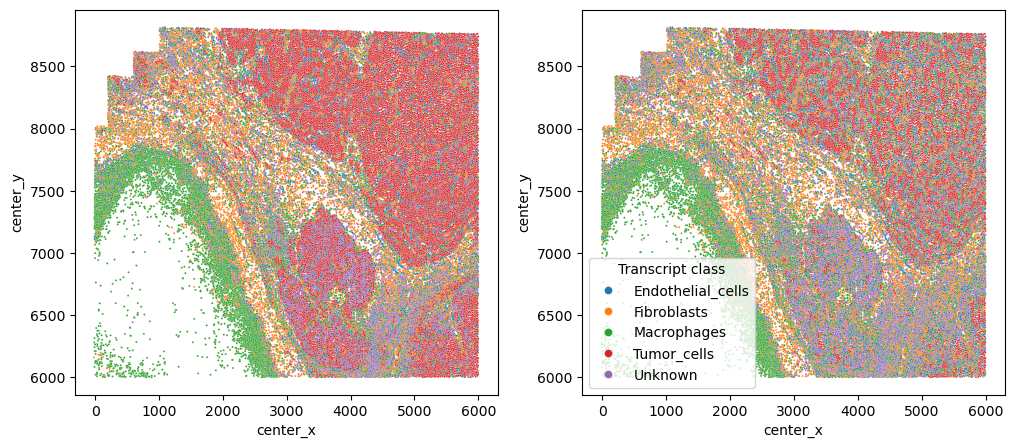

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(adata_subset.obs, x='center_x', y='center_y', hue='cell_type', s=2, ax=axs[0], legend=False)
sns.scatterplot(cell_meta_synthetic, x='center_x', y='center_y', hue='cell_type', s=2, ax=axs[1])
plt.legend(title='Transcript class', markerscale=4)

In [ ]:
tx_meta_interface

tx_type
real        21008632
permuted    15131111
Name: count, dtype: int64

([], [])

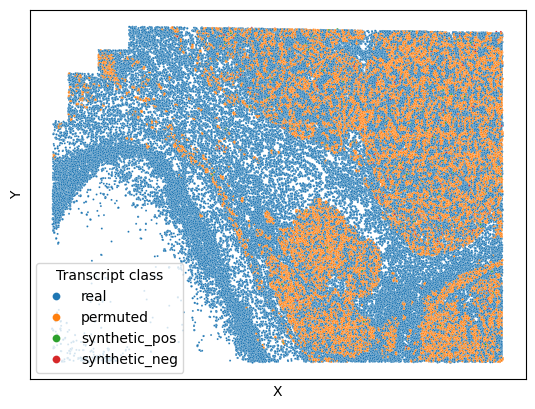

In [ ]:
sns.scatterplot(tx_meta_interface.sample(frac=0.01), x='x', y='y', hue='tx_type', s=2, 
                palette={'real': 'tab:blue', 'permuted': 'tab:orange', 'synthetic_neg': 'tab:red', 'synthetic_pos': 'tab:green'})
plt.legend(title='Transcript class', markerscale=4)
plt.xlabel('X')
plt.ylabel('Y')
plt.xticks([])
plt.yticks([])

([], [])

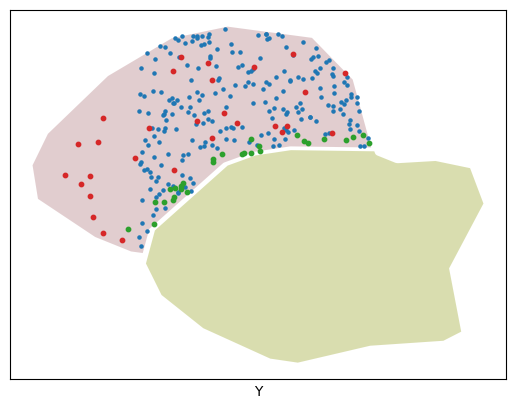

In [196]:
_ = plt.figure()
for cell in tx_meta_interface[tx_meta_interface.tx_type=='synthetic_pos'].cell_id.value_counts().index[:1]:
    cell_tx = tx_meta_interface[tx_meta_interface.cell_id==cell]
    cell_poly = cell_masks.loc[cell,'polygon']
    xs, ys = cell_poly.exterior.xy
    plt.fill(xs, ys, alpha=0.5, fc='#c59da1', ec='none')
    neighbor  = cell_tx.neighbor.dropna().unique()[0]
    cell_poly = cell_masks.loc[neighbor,'polygon']
    xs, ys = cell_poly.exterior.xy
    plt.fill(xs, ys, alpha=0.5, fc='#b5bd61', ec='none')
    texts = []
    mask = cell_tx.tx_type=='real'
    plt.scatter(cell_tx.loc[mask,'x'], cell_tx.loc[mask,'y'], c='tab:blue', s=5)
    mask_pos = cell_tx.tx_type=='synthetic_pos'
    plt.scatter(cell_tx.loc[mask_pos,'x'], cell_tx.loc[mask_pos,'y'], c= 'tab:green', s=10)
    mask_neg = cell_tx.tx_type=='synthetic_neg'
    plt.scatter(cell_tx.loc[mask_neg,'x'], cell_tx.loc[mask_neg,'y'], c= 'tab:red', s=10)
plt.xlabel('X')
plt.xlabel('Y')
plt.xticks([])
plt.yticks([])

[]

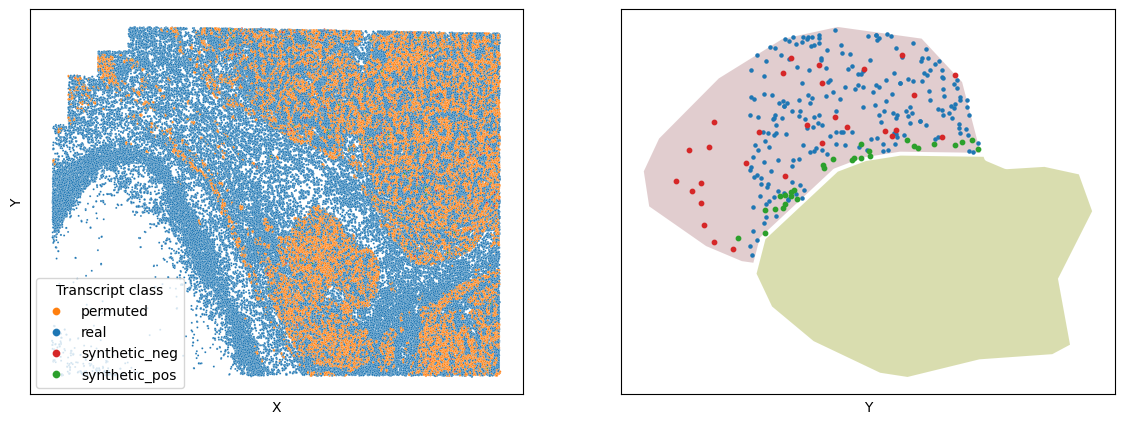

In [199]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(tx_meta_interface.sample(frac=0.01), x='x', y='y', hue='tx_type', s=2, 
                palette={'real': 'tab:blue', 'permuted': 'tab:orange', 'synthetic_neg': 'tab:red', 'synthetic_pos': 'tab:green'}, ax=axs[0])
axs[0].legend(title='Transcript class', markerscale=4)
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[0].set_xticks([])
axs[0].set_yticks([])

for cell in tx_meta_interface[tx_meta_interface.tx_type=='synthetic_pos'].cell_id.value_counts().index[:1]:
    cell_tx = tx_meta_interface[tx_meta_interface.cell_id==cell]
    cell_poly = cell_masks.loc[cell,'polygon']
    xs, ys = cell_poly.exterior.xy
    axs[1].fill(xs, ys, alpha=0.5, fc='#c59da1', ec='none')
    neighbor  = cell_tx.neighbor.dropna().unique()[0]
    cell_poly = cell_masks.loc[neighbor,'polygon']
    xs, ys = cell_poly.exterior.xy
    axs[1].fill(xs, ys, alpha=0.5, fc='#b5bd61', ec='none')
    texts = []
    mask = cell_tx.tx_type=='real'
    axs[1].scatter(cell_tx.loc[mask,'x'], cell_tx.loc[mask,'y'], c='tab:blue', s=5)
    mask_pos = cell_tx.tx_type=='synthetic_pos'
    axs[1].scatter(cell_tx.loc[mask_pos,'x'], cell_tx.loc[mask_pos,'y'], c= 'tab:green', s=10)
    mask_neg = cell_tx.tx_type=='synthetic_neg'
    axs[1].scatter(cell_tx.loc[mask_neg,'x'], cell_tx.loc[mask_neg,'y'], c= 'tab:red', s=10)
axs[1].set_xlabel('X')
axs[1].set_xlabel('Y')
axs[1].set_xticks([])
axs[1].set_yticks([])